# Manufacturing Machine Sensor Forecasting with Google TimesFM

## Problem Statement

Machines continuously stream sensor readings (temperature, pressure, vibration proxies, current, switches).

Instead of waiting for failures, we forecast **future machine temperature** and convert forecasts into:

- abnormal trend detection,
- maintenance scheduling recommendations,
- actions to reduce downtime risk.

We implement this end-to-end on a real industrial compressor dataset.

## Business Context and Mapping

- **Industry:** Manufacturing / Industrial Operations
- **Input:** Timestamped machine sensor streams
- **Target Forecast:** Future `motor_temperature_c` (proxied by compressor `Oil_temperature`)
- **Goal:** Detect risky thermal trends early and schedule maintenance before failure

In [1]:
from __future__ import annotations

import math
import os
import subprocess
import zipfile
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

np.random.seed(42)

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
DATA_DIR = PROJECT_ROOT / 'data' / 'manufacturing'
RAW_DIR = DATA_DIR / 'raw'
ART_DIR = PROJECT_ROOT / 'artifacts' / 'manufacturing_sensor_timesfm'

RAW_DIR.mkdir(parents=True, exist_ok=True)
ART_DIR.mkdir(parents=True, exist_ok=True)

CSV_PATH = RAW_DIR / 'MetroPT3(AirCompressor).csv'

print('Project root:', PROJECT_ROOT)
print('CSV path:', CSV_PATH)
print('Artifacts dir:', ART_DIR)

Project root: /home/ahmad/AI/Github/google-TimesFM-implementation
CSV path: /home/ahmad/AI/Github/google-TimesFM-implementation/data/manufacturing/raw/MetroPT3(AirCompressor).csv
Artifacts dir: /home/ahmad/AI/Github/google-TimesFM-implementation/artifacts/manufacturing_sensor_timesfm


## 1) Download Data from Web (Kaggle)

Dataset: **MetroPT3 Air Compressor** (`anshtanwar/metro-train-dataset`)

This dataset includes timestamped pressure, current, valves/switches, and temperature channels.

The cell below:
- uses local file if already available,
- otherwise downloads from Kaggle via CLI.

In [2]:
def ensure_dataset(csv_path: Path) -> Path:
    if csv_path.exists():
        print(f'Found local dataset: {csv_path}')
        return csv_path

    zip_path = RAW_DIR / 'metro-train-dataset.zip'
    cmd = [
        'kaggle', 'datasets', 'download',
        '-d', 'anshtanwar/metro-train-dataset',
        '-p', str(RAW_DIR),
        '--force',
    ]

    try:
        print('Downloading dataset from Kaggle...')
        subprocess.run(cmd, check=True, capture_output=True, text=True)
    except Exception as exc:
        raise RuntimeError(
            'Kaggle download failed. Configure Kaggle API credentials or place '
            f'`{csv_path.name}` under {csv_path.parent}.'
        ) from exc

    if zip_path.exists():
        with zipfile.ZipFile(zip_path, 'r') as zf:
            zf.extractall(RAW_DIR)

    if not csv_path.exists():
        raise FileNotFoundError(f'Expected file not found after download: {csv_path}')

    return csv_path

csv_path = ensure_dataset(CSV_PATH)
csv_path

Found local dataset: /home/ahmad/AI/Github/google-TimesFM-implementation/data/manufacturing/raw/MetroPT3(AirCompressor).csv


PosixPath('/home/ahmad/AI/Github/google-TimesFM-implementation/data/manufacturing/raw/MetroPT3(AirCompressor).csv')

## 2) Load and Prepare Sensor Time Series

We map `Oil_temperature` to `motor_temperature_c` as the thermal behavior proxy.

Data frequency is approximately 10 seconds. For robust forecasting and faster production operation,
we aggregate to **1-minute resolution**.

In [3]:
usecols = [
    'timestamp',
    'Oil_temperature',
    'TP2',
    'TP3',
    'DV_pressure',
    'Reservoirs',
    'Motor_current',
    'COMP',
    'Pressure_switch',
]

raw_df = pd.read_csv(csv_path, usecols=usecols, parse_dates=['timestamp'])
raw_df = raw_df.sort_values('timestamp').drop_duplicates('timestamp')

print('Raw rows:', len(raw_df))
print('Date range:', raw_df['timestamp'].min(), '->', raw_df['timestamp'].max())

# Resample to one-minute mean (manufacturing control-friendly cadence)
df = raw_df.set_index('timestamp').resample('1min').mean()
df = df.interpolate(limit_direction='both')

df = df.rename(columns={'Oil_temperature': 'motor_temperature_c'})

print('Resampled rows (1min):', len(df))
print('Nulls after interpolation:', int(df.isna().sum().sum()))
df.head()

Raw rows: 1516948
Date range: 2020-02-01 00:00:00 -> 2020-09-01 03:59:50
Resampled rows (1min): 306960
Nulls after interpolation: 0


,TP2,TP3,DV_pressure,Reservoirs,motor_temperature_c,Motor_current,COMP,Pressure_switch
timestamp,,,,,,,,
2020-02-01 00:00:00,-0.012286,9.327429,-0.022857,9.328000,53.521429,0.040357,1.0,1.0
2020-02-01 00:01:00,-0.013000,9.260000,-0.023333,9.259667,53.420833,0.040000,1.0,1.0
2020-02-01 00:02:00,-0.012667,9.198333,-0.022333,9.199000,53.325000,0.040000,1.0,1.0
2020-02-01 00:03:00,-0.012333,9.136667,-0.022667,9.136667,53.200000,0.040000,1.0,1.0
2020-02-01 00:04:00,-0.013000,9.075667,-0.023000,9.075667,53.129167,0.040000,1.0,1.0


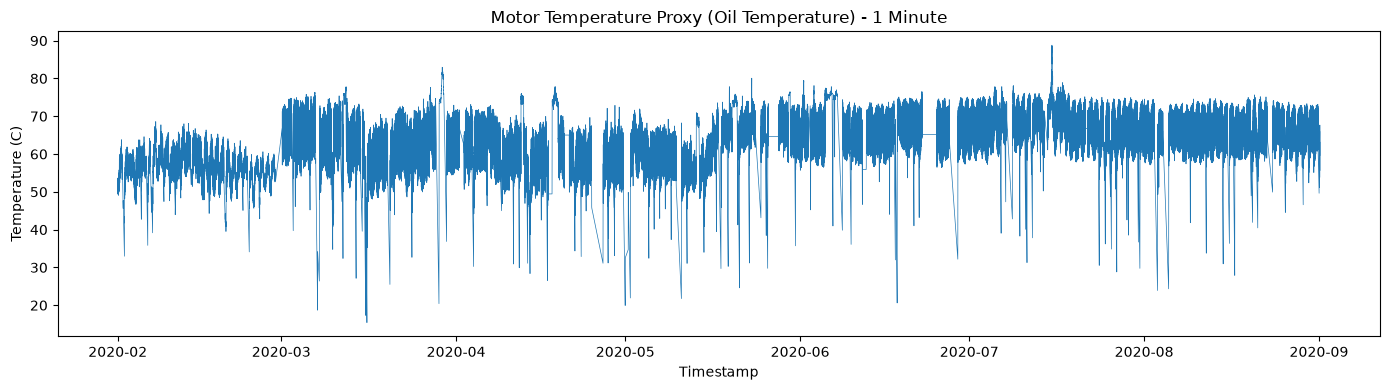

In [4]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df.index, df['motor_temperature_c'], lw=0.5)
ax.set_title('Motor Temperature Proxy (Oil Temperature) - 1 Minute')
ax.set_ylabel('Temperature (C)')
ax.set_xlabel('Timestamp')
plt.tight_layout()
plt.show()

## 3) Forecasting Setup

Forecast horizons at 1-minute granularity:

- `H=1`: next minute (ultra-short control)
- `H=60`: next hour (operations planning)
- `H=360`: next 6 hours (maintenance planning window)

We run rolling backtests across recent anchors.

In [5]:
@dataclass
class Config:
    context_len: int = 1024          # ~17 hours at 1-min resolution
    max_horizon: int = 360           # 6 hours
    eval_horizons: tuple[int, ...] = (1, 60, 360)
    # backtest anchors offset in minutes
    anchor_offsets: tuple[int, ...] = (7*24*60, 5*24*60, 3*24*60, 1*24*60)
    per_core_batch_size: int = 8
    xreg_mode: str = 'xreg + timesfm'
    xreg_ridge: float = 1e-3

cfg = Config()

last_pos = len(df) - 1
anchor_positions: list[int] = []
for offset in cfg.anchor_offsets:
    end_pos = last_pos - offset
    if end_pos - cfg.context_len + 1 >= 0 and end_pos + cfg.max_horizon < len(df):
        anchor_positions.append(end_pos)

print('Anchor count:', len(anchor_positions))
print('Anchor timestamps:')
for pos in anchor_positions:
    print(' -', df.index[pos])

Anchor count: 4
Anchor timestamps:
 - 2020-08-25 03:59:00
 - 2020-08-27 03:59:00
 - 2020-08-29 03:59:00
 - 2020-08-31 03:59:00


## 4) Load TimesFM and Build Helpers

In [6]:
os.environ.setdefault('CUDA_VISIBLE_DEVICES', '')

import timesfm

model = timesfm.TimesFM_2p5_200M_torch.from_pretrained('google/timesfm-2.5-200m-pytorch')
fc = timesfm.ForecastConfig(
    max_context=cfg.context_len,
    max_horizon=cfg.max_horizon,
    normalize_inputs=True,
    per_core_batch_size=cfg.per_core_batch_size,
    use_continuous_quantile_head=True,
    force_flip_invariance=True,
    infer_is_positive=True,
    fix_quantile_crossing=True,
    return_backcast=True,
)
model.compile(fc)
print('TimesFM model compiled.')

TimesFM model compiled.


In [7]:
def build_time_covariates(start_ts: pd.Timestamp, context_len: int, horizon: int) -> dict[str, list[list[float]]]:
    full_idx = pd.date_range(start_ts, periods=context_len + horizon, freq='1min')
    minute = full_idx.minute.values.astype(np.float32)
    hour = full_idx.hour.values.astype(np.float32)
    dow = full_idx.dayofweek.values.astype(np.float32)

    return {
        'min_sin': [np.sin(2 * np.pi * minute / 60.0).astype(np.float32).tolist()],
        'min_cos': [np.cos(2 * np.pi * minute / 60.0).astype(np.float32).tolist()],
        'hour_sin': [np.sin(2 * np.pi * hour / 24.0).astype(np.float32).tolist()],
        'hour_cos': [np.cos(2 * np.pi * hour / 24.0).astype(np.float32).tolist()],
        'dow_sin': [np.sin(2 * np.pi * dow / 7.0).astype(np.float32).tolist()],
        'dow_cos': [np.cos(2 * np.pi * dow / 7.0).astype(np.float32).tolist()],
        'is_weekend': [(dow >= 5).astype(np.float32).tolist()],
    }


def forecast_temperature(context: np.ndarray, start_ts: pd.Timestamp, horizon: int) -> tuple[np.ndarray, np.ndarray]:
    dyn_num = build_time_covariates(start_ts, len(context), horizon)

    try:
        point, quant = model.forecast_with_covariates(
            inputs=[context.astype(np.float32)],
            dynamic_numerical_covariates=dyn_num,
            xreg_mode=cfg.xreg_mode,
            ridge=cfg.xreg_ridge,
        )
    except Exception:
        point, quant = model.forecast(horizon=horizon, inputs=[context.astype(np.float32)])

    point_np = np.asarray(point, dtype=np.float32)[0, :horizon]
    quant_np = np.asarray(quant, dtype=np.float32)[0, :horizon, :]

    point_np = np.clip(point_np, 0.0, None)
    quant_np = np.clip(quant_np, 0.0, None)

    return point_np, quant_np


def wmape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.abs(y_true - y_pred).sum() / (np.abs(y_true).sum() + 1e-8))

## 5) Rolling Backtest (TimesFM vs Baselines)

Baselines:
- `naive_last`: last value persistence
- `seasonal60`: repeat last 60-minute pattern

In [8]:
records: list[dict] = []
latest_forecast = None
latest_actual = None
latest_anchor_ts = None

for anchor_pos in anchor_positions:
    y_ctx = df['motor_temperature_c'].iloc[anchor_pos - cfg.context_len + 1 : anchor_pos + 1].to_numpy(np.float32)
    y_true = df['motor_temperature_c'].iloc[anchor_pos + 1 : anchor_pos + cfg.max_horizon + 1].to_numpy(np.float32)

    start_ts = df.index[anchor_pos - cfg.context_len + 1]
    anchor_ts = df.index[anchor_pos]

    tfm_pred, tfm_quant = forecast_temperature(y_ctx, start_ts, cfg.max_horizon)

    naive_last = np.repeat(y_ctx[-1], cfg.max_horizon)
    seasonal60 = np.tile(y_ctx[-60:], math.ceil(cfg.max_horizon / 60))[: cfg.max_horizon]

    for hz in cfg.eval_horizons:
        y = y_true[:hz]
        for name, pred in {
            'timesfm': tfm_pred[:hz],
            'naive_last': naive_last[:hz],
            'seasonal60': seasonal60[:hz],
        }.items():
            records.append(
                {
                    'anchor_ts': anchor_ts,
                    'horizon_min': hz,
                    'model': name,
                    'mae': mean_absolute_error(y, pred),
                    'rmse': mean_squared_error(y, pred) ** 0.5,
                    'wmape': wmape(y, pred),
                }
            )

    if anchor_pos == max(anchor_positions):
        latest_anchor_ts = anchor_ts
        latest_actual = y_true.copy()
        latest_forecast = pd.DataFrame(
            {
                'timestamp': pd.date_range(anchor_ts + pd.Timedelta(minutes=1), periods=cfg.max_horizon, freq='1min'),
                'timesfm_p50_c': tfm_pred,
                'timesfm_q10_c': tfm_quant[:, 1],
                'timesfm_q90_c': tfm_quant[:, 9],
                'naive_last_c': naive_last,
                'seasonal60_c': seasonal60,
            }
        )

metrics = (
    pd.DataFrame(records)
    .groupby(['horizon_min', 'model'], as_index=False)[['mae', 'rmse', 'wmape']]
    .mean()
    .sort_values(['horizon_min', 'rmse'])
)

metrics

ERROR:jax._src.xla_bridge:Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/ahmad/AI/Github/google-TimesFM-implementation/.venv/lib/python3.14/site-packages/jax/_src/xla_bridge.py", line 508, in discover_pjrt_plugins
    plugin_module.initialize()
    ~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/home/ahmad/AI/Github/google-TimesFM-implementation/.venv/lib/python3.14/site-packages/jax_plugins/xla_cuda12/__init__.py", line 370, in initialize
    _check_cuda_versions(raise_on_first_error = True)
    ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/ahmad/AI/Github/google-TimesFM-implementation/.venv/lib/python3.14/site-packages/jax_plugins/xla_cuda12/__init__.py", line 274, in _check_cuda_versions
    for d in range(cuda_versions.cuda_device_count())
                   ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:135: operation cuInit(0) failed: CUDA_ERROR_NO_D

,horizon_min,model,mae,rmse,wmape
2,1,timesfm,0.245941,0.245941,0.004294
0,1,naive_last,0.266757,0.266757,0.004586
1,1,seasonal60,7.329462,7.329462,0.127717
5,60,timesfm,1.621104,2.376394,0.027229
3,60,naive_last,3.507592,4.405978,0.058437
4,60,seasonal60,4.423099,4.910122,0.075576
7,360,seasonal60,5.644226,6.473237,0.089552
8,360,timesfm,6.107776,7.207093,0.098138
6,360,naive_last,6.692507,7.678762,0.106132


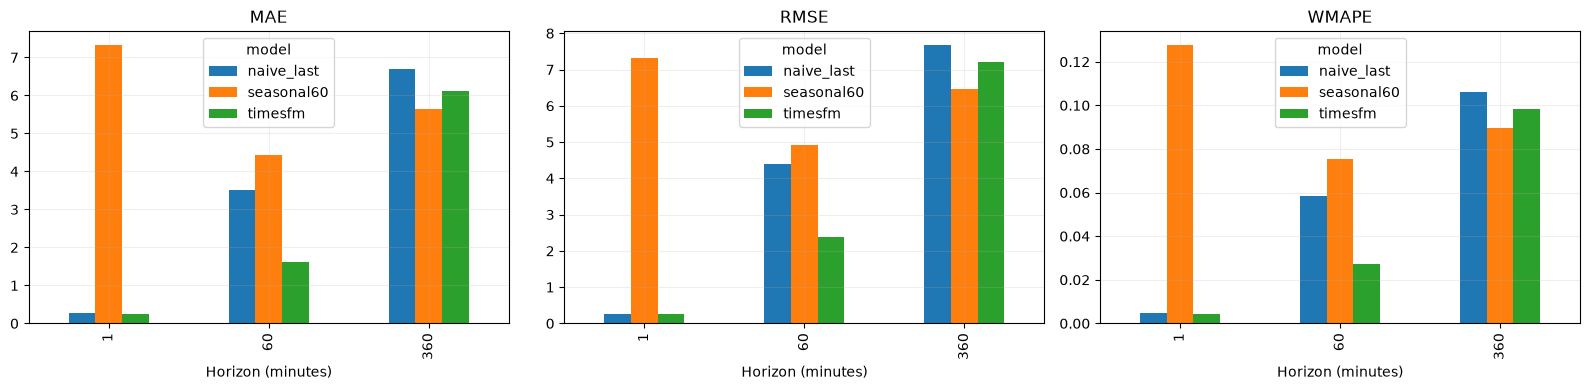

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=False)
for ax, metric in zip(axes, ['mae', 'rmse', 'wmape']):
    pivot = metrics.pivot(index='horizon_min', columns='model', values=metric)
    pivot.plot(kind='bar', ax=ax)
    ax.set_title(metric.upper())
    ax.set_xlabel('Horizon (minutes)')
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 6) Forecast Future Trends and Detect Abnormal Thermal Behavior

We generate rules that operations teams can act on:

- **Warning** when forecast p50 crosses high historical percentile.
- **Critical** when forecast q90 crosses critical threshold.
- **Persistent alarms** when threshold breaches continue for multiple minutes.

These are then converted into maintenance schedule recommendations.

In [10]:
# Historical thresholds from recent baseline window.
baseline_window = df['motor_temperature_c'].iloc[-7*24*60:]
warning_thr = float(np.quantile(baseline_window, 0.990))
critical_thr = float(np.quantile(baseline_window, 0.995))

alerts = latest_forecast.copy()
alerts['warning_flag'] = alerts['timesfm_p50_c'] >= warning_thr
alerts['critical_flag'] = alerts['timesfm_q90_c'] >= critical_thr

# Consecutive run length helper

def run_length(flags: pd.Series) -> pd.Series:
    grp = (flags != flags.shift()).cumsum()
    return flags.groupby(grp).cumcount() + 1

alerts['warning_run'] = run_length(alerts['warning_flag'])
alerts['critical_run'] = run_length(alerts['critical_flag'])

alerts['abnormal_future_trend'] = (
    (alerts['critical_flag'] & (alerts['critical_run'] >= 5))
    | (alerts['warning_flag'] & (alerts['warning_run'] >= 15))
)

print(f'Warning threshold: {warning_thr:.2f} C')
print(f'Critical threshold: {critical_thr:.2f} C')
print('Abnormal future points:', int(alerts['abnormal_future_trend'].sum()))

alerts[['timestamp', 'timesfm_p50_c', 'timesfm_q90_c', 'warning_flag', 'critical_flag', 'abnormal_future_trend']].head(20)

Warning threshold: 72.35 C
Critical threshold: 72.62 C
Abnormal future points: 0


,timestamp,timesfm_p50_c,timesfm_q90_c,warning_flag,critical_flag,abnormal_future_trend
0,2020-08-31 04:00:00,58.396706,59.625355,False,False,False
1,2020-08-31 04:01:00,58.741486,60.673325,False,False,False
2,2020-08-31 04:02:00,59.231964,61.669559,False,False,False
3,2020-08-31 04:03:00,59.889610,62.817444,False,False,False
4,2020-08-31 04:04:00,60.595768,63.732353,False,False,False
5,2020-08-31 04:05:00,61.350582,64.622749,False,False,False
6,2020-08-31 04:06:00,62.399960,65.770195,False,False,False
7,2020-08-31 04:07:00,63.517044,66.943062,False,False,False
8,2020-08-31 04:08:00,64.328255,67.617363,False,False,False
9,2020-08-31 04:09:00,64.651649,67.984222,False,False,False


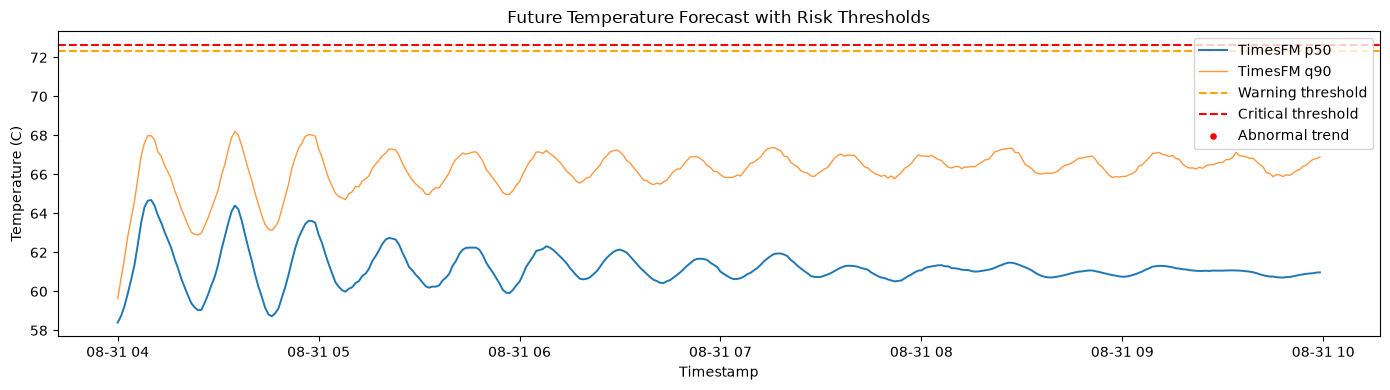

In [11]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(alerts['timestamp'], alerts['timesfm_p50_c'], label='TimesFM p50', lw=1.4)
ax.plot(alerts['timestamp'], alerts['timesfm_q90_c'], label='TimesFM q90', lw=1.0, alpha=0.8)
ax.axhline(warning_thr, color='orange', linestyle='--', label='Warning threshold')
ax.axhline(critical_thr, color='red', linestyle='--', label='Critical threshold')

abn = alerts[alerts['abnormal_future_trend']]
ax.scatter(abn['timestamp'], abn['timesfm_p50_c'], color='red', s=14, label='Abnormal trend')

ax.set_title('Future Temperature Forecast with Risk Thresholds')
ax.set_ylabel('Temperature (C)')
ax.set_xlabel('Timestamp')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

## 7) Maintenance Scheduling Recommendations

We convert abnormal future intervals into actionable maintenance windows.

Policy used here:
- create windows from contiguous abnormal intervals,
- classify severity by max predicted q90 in the window,
- produce lead-time recommendations.

In [12]:
ab = alerts[['timestamp', 'abnormal_future_trend', 'timesfm_p50_c', 'timesfm_q90_c']].copy()
ab['grp'] = (ab['abnormal_future_trend'] != ab['abnormal_future_trend'].shift()).cumsum()

windows = (
    ab[ab['abnormal_future_trend']]
    .groupby('grp', as_index=False)
    .agg(
        start_ts=('timestamp', 'min'),
        end_ts=('timestamp', 'max'),
        duration_min=('timestamp', lambda s: int((s.max() - s.min()).total_seconds() / 60) + 1),
        peak_p50_c=('timesfm_p50_c', 'max'),
        peak_q90_c=('timesfm_q90_c', 'max'),
    )
)

if len(windows) == 0:
    schedule = pd.DataFrame(
        [{
            'maintenance_action': 'No urgent thermal anomaly predicted in next 6 hours',
            'priority': 'Low',
            'recommended_start': pd.NaT,
            'recommended_end': pd.NaT,
            'reason': 'Forecast remains below warning/critical thermal thresholds',
        }]
    )
else:
    schedule = windows.copy()
    schedule['priority'] = np.where(schedule['peak_q90_c'] >= critical_thr, 'High', 'Medium')
    schedule['recommended_start'] = schedule['start_ts'] - pd.Timedelta(minutes=20)
    schedule['recommended_end'] = schedule['end_ts'] + pd.Timedelta(minutes=10)
    schedule['maintenance_action'] = np.where(
        schedule['priority'] == 'High',
        'Inspect cooling/lubrication loop and load control immediately',
        'Schedule preventive check on compressor thermal path',
    )
    schedule['reason'] = (
        'Predicted persistent abnormal temperature trend with elevated uncertainty band'
    )

schedule

,maintenance_action,priority,recommended_start,recommended_end,reason
0,No urgent thermal anomaly predicted in next 6 ...,Low,NaT,NaT,Forecast remains below warning/critical therma...


## 8) Downtime-Risk Proxy and Cost-Oriented Interpretation

We compute a simple risk proxy based on forecast excess over threshold.

This is not a failure-probability model; it is an operational prioritization metric.

In [13]:
alerts['excess_over_warning'] = np.clip(alerts['timesfm_p50_c'] - warning_thr, 0, None)
alerts['excess_over_critical_q90'] = np.clip(alerts['timesfm_q90_c'] - critical_thr, 0, None)

# Weighted risk score per minute
alerts['risk_score'] = 1.0 * alerts['excess_over_warning'] + 2.0 * alerts['excess_over_critical_q90']

total_risk = float(alerts['risk_score'].sum())
critical_minutes = int((alerts['critical_flag']).sum())

print(f'Total future risk score (next 6h): {total_risk:.2f}')
print(f'Critical-flag minutes (next 6h): {critical_minutes}')

Total future risk score (next 6h): 0.00
Critical-flag minutes (next 6h): 0


In [14]:
metrics_path = ART_DIR / 'backtest_metrics.csv'
forecast_path = ART_DIR / 'future_temperature_forecast.csv'
alerts_path = ART_DIR / 'future_temperature_alerts.csv'
schedule_path = ART_DIR / 'maintenance_schedule.csv'

metrics.to_csv(metrics_path, index=False)
latest_forecast.to_csv(forecast_path, index=False)
alerts.to_csv(alerts_path, index=False)
schedule.to_csv(schedule_path, index=False)

print('Saved:', metrics_path)
print('Saved:', forecast_path)
print('Saved:', alerts_path)
print('Saved:', schedule_path)

Saved: /home/ahmad/AI/Github/google-TimesFM-implementation/artifacts/manufacturing_sensor_timesfm/backtest_metrics.csv
Saved: /home/ahmad/AI/Github/google-TimesFM-implementation/artifacts/manufacturing_sensor_timesfm/future_temperature_forecast.csv
Saved: /home/ahmad/AI/Github/google-TimesFM-implementation/artifacts/manufacturing_sensor_timesfm/future_temperature_alerts.csv
Saved: /home/ahmad/AI/Github/google-TimesFM-implementation/artifacts/manufacturing_sensor_timesfm/maintenance_schedule.csv


## Final Output Summary

This notebook delivers:

1. Forecasts of future machine temperature for 1-min, 60-min, and 360-min horizons.
2. Abnormal-future-trend detection from uncertainty-aware thresholds.
3. Maintenance schedule recommendations with priority and timing.
4. Exported artifacts for operations integration.

For production deployment, connect this pipeline to live sensor streams and run on a rolling cadence (for example every 5 minutes).